# Underperforming Prompts Analysis

This notebook provides an in-depth analysis of prompts that obtained the worst results in EXP4 to identify their common characteristics and potential model weaknesses.

## Objectives

1. **Identify problematic prompts**: Find prompts with the worst F1 scores
2. **Comparative analysis**: Compare metrics between good and bad prompts
3. **Characterization**: Extract all possible metrics from the prompts
4. **Pattern search**: Identify what problematic prompts have in common
5. **Find more candidates**: Search for similar prompts to validate hypotheses

## Hypotheses to Investigate

- **Orientation**: Do bad prompts have specific orientations?
- **Image quality**: Lower SNR or artifacts?
- **Embedding similarity**: Are embeddings outliers?
- **Frequency characteristics**: Different missing wedge or noise?
- **Location**: Does position in the tomogram affect performance?

In [53]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths
from paths import (
    UMU_SYNTH_DIR,
    UMU_SYNTH_TOMOS_DIR,
    UMU_SYNTH_CSV,
    TOMOTWIN_MODEL_FILE,
    PROPICKER_TOOLS_DIR,
    EXP4_RESULTS_DIR,
    EXP4_DATA_DIR,
    EXP4_PROMPTS_DIR,
    EXP4_INFERENCE_DIR,
    EXP4_COORDS_DIR,
)

# Import config
from experiments.config import (
    setup_propicker_paths,
    THYROGLOBULIN_NAME,
    THYROGLOBULIN_LABEL,
    PROMPT_SIZE,
    PROMPT_HALF,
    EXP4_VAL_TOMOS,
    EXP4_TRAIN_POOL,
)

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

import json
import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.spatial.transform import Rotation
from scipy.spatial.distance import cdist
from scipy import stats
from scipy.fft import fftn, fftshift
import mrcfile

from utils.mrctools import load_mrc_data

import warnings
warnings.filterwarnings("ignore")

# Output directory for this analysis
ANALYSIS_DIR = EXP4_RESULTS_DIR / "underperforming_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"EXP4 results: {EXP4_RESULTS_DIR}")
print(f"Analysis output: {ANALYSIS_DIR}")

Project root: /home/carloshg/Dev/cryoet-particle-picking
EXP4 results: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations
Analysis output: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/underperforming_analysis


## 1. Load Inference Results and Identify Problematic Prompts

In [54]:
def compute_metrics(pred_coords, gt_coords, distance_threshold=15.0):
    """
    Compute precision, recall, and F1 score.
    """
    if len(pred_coords) == 0:
        return {'precision': 0, 'recall': 0, 'f1': 0, 'tp': 0, 'fp': 0, 'fn': len(gt_coords)}
    
    if len(gt_coords) == 0:
        return {'precision': 0, 'recall': 0, 'f1': 0, 'tp': 0, 'fp': len(pred_coords), 'fn': 0}
    
    # Compute distance matrix
    distances = cdist(pred_coords, gt_coords)
    
    # Match predictions to ground truth (greedy)
    tp = 0
    matched_gt = set()
    
    for i in range(len(pred_coords)):
        min_dist = float('inf')
        best_j = -1
        
        for j in range(len(gt_coords)):
            if j not in matched_gt and distances[i, j] < min_dist:
                min_dist = distances[i, j]
                best_j = j
        
        if best_j != -1 and min_dist <= distance_threshold:
            tp += 1
            matched_gt.add(best_j)
    
    fp = len(pred_coords) - tp
    fn = len(gt_coords) - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }


def load_predicted_coords(result_dir, tomo_name):
    """Load predicted coordinates from a result directory."""
    coords_file = result_dir / "PredictedLabels" / "Coords_All" / f"{tomo_name}.coords"
    
    if coords_file.exists():
        df = pd.read_csv(coords_file, sep='\t', header=None, names=['class_id', 'x', 'y', 'z'])
        return df[['x', 'y', 'z']].values
    
    return np.array([]).reshape(0, 3)


def load_gt_coords(tomo_name):
    """Load ground truth coordinates."""
    coords_file = EXP4_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    
    if coords_file.exists():
        df = pd.read_csv(coords_file)
        return df[['X', 'Y', 'Z']].values
    
    return np.array([]).reshape(0, 3)

In [55]:
print("=" * 70)
print("LOADING INFERENCE RESULTS")
print("=" * 70)

all_results = []
inference_dir = EXP4_RESULTS_DIR / "inference"

for result_dir in sorted(inference_dir.glob("*")):
    if not result_dir.is_dir():
        continue
    
    # Parse result name: base_promptX or {single,multi}_incY_promptX
    name = result_dir.name
    
    if name.startswith("base_"):
        checkpoint_type = "base"
        increment = 0
        prompt_idx = int(name.split("prompt")[1])
    else:
        parts = name.split("_")
        checkpoint_type = parts[0]
        increment = int(parts[1].replace("inc", ""))
        prompt_idx = int(parts[2].replace("prompt", ""))
    
    # Compute metrics for each validation tomogram
    for tomo_name in EXP4_VAL_TOMOS:
        pred_coords = load_predicted_coords(result_dir, tomo_name)
        gt_coords = load_gt_coords(tomo_name)
        
        if len(gt_coords) == 0:
            continue
        
        metrics = compute_metrics(pred_coords, gt_coords)
        
        all_results.append({
            'checkpoint_type': checkpoint_type,
            'increment': increment,
            'prompt_idx': prompt_idx,
            'tomo_name': tomo_name,
            'n_pred': len(pred_coords),
            'n_gt': len(gt_coords),
            **metrics
        })

df_results = pd.DataFrame(all_results)
print(f"\n✅ Loaded {len(df_results)} inference results")
print(f"   Checkpoints: {df_results['checkpoint_type'].unique()}")
print(f"   Prompts: {sorted(df_results['prompt_idx'].unique())}")

LOADING INFERENCE RESULTS

✅ Loaded 350 inference results
   Checkpoints: ['base' 'multi' 'single']
   Prompts: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [56]:
# Aggregate metrics by prompt (averaging all tomograms and checkpoints)
print("=" * 70)
print("AVERAGE PERFORMANCE BY PROMPT")
print("=" * 70)

# Calculate average metrics by prompt
df_by_prompt = df_results.groupby('prompt_idx').agg({
    'f1': ['mean', 'std', 'min', 'max'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'tp': 'sum',
    'fp': 'sum',
    'fn': 'sum'
}).round(4)

df_by_prompt.columns = ['_'.join(col).strip() for col in df_by_prompt.columns.values]
df_by_prompt = df_by_prompt.reset_index()

# Sort by F1 mean to identify the worst ones
df_by_prompt_sorted = df_by_prompt.sort_values('f1_mean', ascending=True)

print("\nPrompts sorted by F1 (worst to best):")
display(df_by_prompt_sorted)

# Identify the 2 worst prompts
worst_prompts = df_by_prompt_sorted.head(2)['prompt_idx'].tolist()
best_prompts = df_by_prompt_sorted.tail(2)['prompt_idx'].tolist()

print(f"\n🔴 Prompts with WORST performance: {worst_prompts}")
print(f"🟢 Prompts with BEST performance: {best_prompts}")

AVERAGE PERFORMANCE BY PROMPT

Prompts sorted by F1 (worst to best):


,prompt_idx,f1_mean,f1_std,f1_min,f1_max,precision_mean,precision_std,recall_mean,recall_std,tp_sum,fp_sum,fn_sum
1,1,0.4761,0.2291,0.0000,0.7300,0.8265,0.3444,0.3415,0.1769,1497,523,2857
3,3,0.6103,0.2755,0.0000,0.9224,0.8251,0.3422,0.4969,0.2505,2177,1064,2177
8,8,0.7249,0.3073,0.0000,0.9266,0.7526,0.3168,0.7021,0.3025,3071,1421,1283
0,0,0.7303,0.3144,0.0000,0.9466,0.7968,0.3355,0.6783,0.3008,2969,1241,1385
2,2,0.7403,0.3120,0.0000,0.9434,0.6869,0.2948,0.8050,0.3350,3513,1337,841
7,7,0.7405,0.2909,0.0712,0.9565,0.7244,0.3003,0.7733,0.2589,3386,2684,968
5,5,0.7573,0.3189,0.0000,0.9520,0.7405,0.3128,0.7762,0.3273,3391,1520,963
4,4,0.7616,0.3217,0.0000,0.9585,0.7061,0.3049,0.8303,0.3449,3619,1301,735
6,6,0.7642,0.3212,0.0000,0.9591,0.7559,0.3173,0.7739,0.3270,3382,1421,972
9,9,0.7666,0.3218,0.0000,0.9547,0.7278,0.3094,0.8114,0.3373,3539,1604,815



🔴 Prompts with WORST performance: [1, 3]
🟢 Prompts with BEST performance: [6, 9]


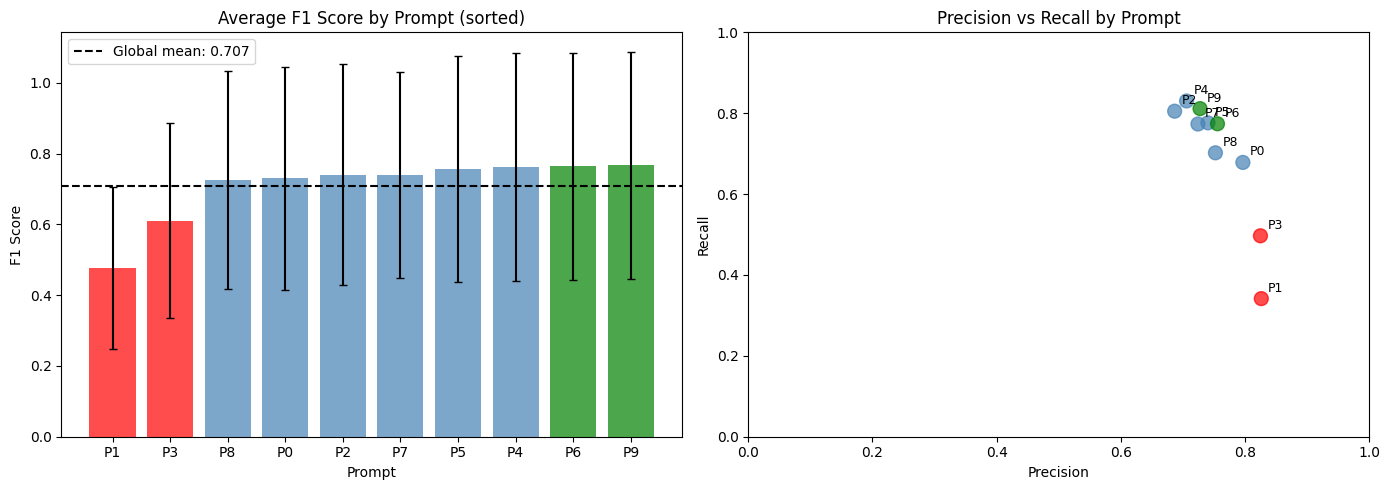


📊 F1 difference between best and worst: 0.2905


In [57]:
# Visualization: F1 by prompt with error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 mean with std
ax1 = axes[0]
colors = ['red' if p in worst_prompts else 'green' if p in best_prompts else 'steelblue' 
          for p in df_by_prompt_sorted['prompt_idx']]

ax1.bar(range(len(df_by_prompt_sorted)), df_by_prompt_sorted['f1_mean'], 
        yerr=df_by_prompt_sorted['f1_std'], color=colors, alpha=0.7, capsize=3)
ax1.set_xticks(range(len(df_by_prompt_sorted)))
ax1.set_xticklabels([f"P{p}" for p in df_by_prompt_sorted['prompt_idx']])
ax1.set_xlabel('Prompt')
ax1.set_ylabel('F1 Score')
ax1.set_title('Average F1 Score by Prompt (sorted)')
ax1.axhline(df_by_prompt['f1_mean'].mean(), color='black', linestyle='--', 
            label=f'Global mean: {df_by_prompt["f1_mean"].mean():.3f}')
ax1.legend()

# Plot 2: Precision vs Recall by prompt
ax2 = axes[1]
colors_scatter = ['red' if p in worst_prompts else 'green' if p in best_prompts else 'steelblue' 
                  for p in df_by_prompt['prompt_idx']]
ax2.scatter(df_by_prompt['precision_mean'], df_by_prompt['recall_mean'], 
            c=colors_scatter, s=100, alpha=0.7)
for i, row in df_by_prompt.iterrows():
    ax2.annotate(f"P{int(row['prompt_idx'])}", 
                 (row['precision_mean'], row['recall_mean']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.set_xlabel('Precision')
ax2.set_ylabel('Recall')
ax2.set_title('Precision vs Recall by Prompt')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(str(ANALYSIS_DIR / 'f1_by_prompt.png'), dpi=150)
plt.show()

print(f"\n📊 F1 difference between best and worst: {df_by_prompt['f1_mean'].max() - df_by_prompt['f1_mean'].min():.4f}")

## 2. Load Prompt Metadata

In [58]:
# Load information from all prompts
print("=" * 70)
print("LOADING PROMPT METADATA")
print("=" * 70)

with open(EXP4_PROMPTS_DIR / "all_rotation_prompts.json", 'r') as f:
    all_prompts_data = json.load(f)

# Create DataFrame with metadata
prompts_metadata = []
embeddings_list = []

for prompt in all_prompts_data['prompts']:
    idx = prompt['index']
    meta = prompt['metadata']
    embedding = np.array(prompt['embedding'])
    
    prompts_metadata.append({
        'prompt_idx': idx,
        'tomo_name': meta['tomo_name'],
        'x': meta['x'],
        'y': meta['y'],
        'z': meta['z'],
        'q1': meta['q1'],
        'q2': meta['q2'],
        'q3': meta['q3'],
        'q4': meta['q4'],
    })
    embeddings_list.append(embedding)

df_prompts = pd.DataFrame(prompts_metadata)
embeddings = np.array(embeddings_list)

# Extract SNR from tomogram name
df_prompts['snr'] = df_prompts['tomo_name'].apply(
    lambda x: float(x.split('snr')[1]) if 'snr' in x else np.nan
)

# Add performance metrics
df_prompts = df_prompts.merge(
    df_by_prompt[['prompt_idx', 'f1_mean', 'f1_std', 'precision_mean', 'recall_mean']], 
    on='prompt_idx'
)

# Mark good/bad prompts
df_prompts['category'] = df_prompts['prompt_idx'].apply(
    lambda x: 'bad' if x in worst_prompts else ('good' if x in best_prompts else 'average')
)

print("\nMetadata of all prompts:")
display(df_prompts)

LOADING PROMPT METADATA

Metadata of all prompts:


,prompt_idx,tomo_name,x,y,z,q1,q2,q3,q4,snr,f1_mean,f1_std,precision_mean,recall_mean,category
0,0,tomo_rec_4_snr1.85,457.617626,519.120355,55.376236,0.507200,-0.774060,-0.345494,0.155606,1.85,0.7303,0.3144,0.7968,0.6783,average
1,1,tomo_rec_11_snr1.41,173.395637,337.563676,100.634592,-0.673936,-0.627778,0.382405,-0.073966,1.41,0.4761,0.2291,0.8265,0.3415,bad
2,2,tomo_rec_19_snr1.62,315.685703,439.811202,71.960787,0.347360,0.064824,0.712570,0.606121,1.62,0.7403,0.3120,0.6869,0.8050,average
3,3,tomo_rec_4_snr1.85,245.527963,383.464252,77.620740,-0.393876,0.175664,-0.297672,0.851701,1.85,0.6103,0.2755,0.8251,0.4969,bad
4,4,tomo_rec_19_snr1.62,287.224806,309.400756,65.845846,-0.262117,0.719682,-0.628007,0.137692,1.62,0.7616,0.3217,0.7061,0.8303,average
5,5,tomo_rec_11_snr1.41,350.855369,556.749694,59.482563,-0.584779,-0.550860,-0.569203,0.174913,1.41,0.7573,0.3189,0.7405,0.7762,average
6,6,tomo_rec_19_snr1.62,61.920452,378.827728,130.491091,-0.618175,0.017371,0.226239,-0.752578,1.62,0.7642,0.3212,0.7559,0.7739,good
7,7,tomo_rec_0_snr1.63,393.796041,532.262422,57.640057,0.133626,0.642167,-0.309513,-0.688453,1.63,0.7405,0.2909,0.7244,0.7733,average
8,8,tomo_rec_11_snr1.41,235.338072,68.409266,117.537267,-0.281794,0.003213,0.958864,-0.034086,1.41,0.7249,0.3073,0.7526,0.7021,average
9,9,tomo_rec_11_snr1.41,136.715054,480.728096,77.396209,-0.216686,-0.765773,-0.174306,-0.579876,1.41,0.7666,0.3218,0.7278,0.8114,good


## 3. Orientation Analysis (Quaternions)

In [59]:
def quaternion_to_euler(q1, q2, q3, q4):
    """
    Convert quaternion to Euler angles (in degrees).
    Convention: scalar-last (x, y, z, w)
    """
    r = Rotation.from_quat([q1, q2, q3, q4])
    euler = r.as_euler('xyz', degrees=True)
    return euler


def quaternion_angular_distance(q1, q2):
    """Compute angular distance between two quaternions in degrees."""
    q1 = np.array(q1) / np.linalg.norm(q1)
    q2 = np.array(q2) / np.linalg.norm(q2)
    dot = np.abs(np.dot(q1, q2))
    dot = np.clip(dot, -1.0, 1.0)
    angle_rad = 2 * np.arccos(dot)
    return np.degrees(angle_rad)


# Calculate Euler angles for each prompt
print("=" * 70)
print("ORIENTATION ANALYSIS")
print("=" * 70)

euler_angles = []
for _, row in df_prompts.iterrows():
    euler = quaternion_to_euler(row['q1'], row['q2'], row['q3'], row['q4'])
    euler_angles.append({'euler_x': euler[0], 'euler_y': euler[1], 'euler_z': euler[2]})

df_euler = pd.DataFrame(euler_angles)
df_prompts = pd.concat([df_prompts, df_euler], axis=1)

print("\nEuler angles by prompt:")
display(df_prompts[['prompt_idx', 'category', 'euler_x', 'euler_y', 'euler_z', 'f1_mean']])

ORIENTATION ANALYSIS

Euler angles by prompt:


,prompt_idx,category,euler_x,euler_y,euler_z,f1_mean
0,0,average,135.820493,6.290680,-116.085826,0.7303
1,1,bad,-151.359426,37.466818,95.834012,0.4761
2,2,average,34.386647,-24.610897,91.507349,0.7403
3,3,bad,-50.999524,3.711629,-40.300149,0.6103
4,4,average,-100.067150,-7.529368,-146.288563,0.7616
5,5,average,124.539455,-59.139824,119.794485,0.7573
6,6,good,75.932789,14.688477,-21.976866,0.7642
7,7,average,-76.507096,-53.272238,91.567019,0.7405
8,8,average,1.727644,32.696187,-175.421424,0.7249
9,9,good,117.232570,54.347586,113.624801,0.7666


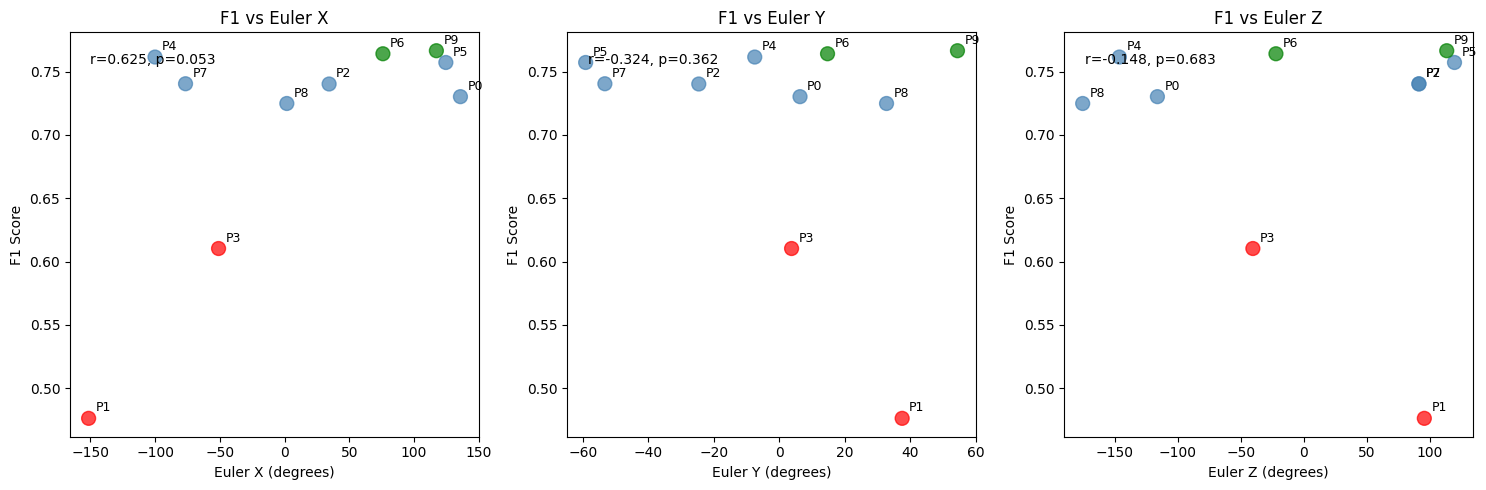

In [60]:
# Visualize Euler angle distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

color_map = {'bad': 'red', 'good': 'green', 'average': 'steelblue'}
colors = [color_map[c] for c in df_prompts['category']]

for i, (ax, angle) in enumerate(zip(axes, ['euler_x', 'euler_y', 'euler_z'])):
    ax.scatter(df_prompts[angle], df_prompts['f1_mean'], c=colors, s=100, alpha=0.7)
    for _, row in df_prompts.iterrows():
        ax.annotate(f"P{int(row['prompt_idx'])}", 
                    (row[angle], row['f1_mean']),
                    textcoords="offset points", xytext=(5, 5), fontsize=9)
    ax.set_xlabel(f'{angle.replace("_", " ").title()} (degrees)')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'F1 vs {angle.replace("_", " ").title()}')
    
    # Calculate correlation
    corr, pval = stats.pearsonr(df_prompts[angle], df_prompts['f1_mean'])
    ax.text(0.05, 0.95, f'r={corr:.3f}, p={pval:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.savefig(str(ANALYSIS_DIR / 'euler_angles_vs_f1.png'), dpi=150)
plt.show()

In [61]:
# Compare orientation statistics between good and bad prompts
print("=" * 70)
print("ORIENTATION COMPARISON: GOOD vs BAD")
print("=" * 70)

df_bad = df_prompts[df_prompts['category'] == 'bad']
df_good = df_prompts[df_prompts['category'] == 'good']

print("\n📊 Euler angle statistics:")
print("\nBAD prompts:")
print(df_bad[['prompt_idx', 'euler_x', 'euler_y', 'euler_z']].to_string(index=False))
print(f"  Mean: X={df_bad['euler_x'].mean():.1f}°, Y={df_bad['euler_y'].mean():.1f}°, Z={df_bad['euler_z'].mean():.1f}°")

print("\nGOOD prompts:")
print(df_good[['prompt_idx', 'euler_x', 'euler_y', 'euler_z']].to_string(index=False))
print(f"  Mean: X={df_good['euler_x'].mean():.1f}°, Y={df_good['euler_y'].mean():.1f}°, Z={df_good['euler_z'].mean():.1f}°")

ORIENTATION COMPARISON: GOOD vs BAD

📊 Euler angle statistics:

BAD prompts:
 prompt_idx     euler_x   euler_y    euler_z
          1 -151.359426 37.466818  95.834012
          3  -50.999524  3.711629 -40.300149
  Mean: X=-101.2°, Y=20.6°, Z=27.8°

GOOD prompts:
 prompt_idx    euler_x   euler_y    euler_z
          6  75.932789 14.688477 -21.976866
          9 117.232570 54.347586 113.624801
  Mean: X=96.6°, Y=34.5°, Z=45.8°


## 4. Embedding Analysis (TomoTwin)

In [62]:
print("=" * 70)
print("EMBEDDING ANALYSIS")
print("=" * 70)

# Calculate distances between embeddings
embedding_distances = cdist(embeddings, embeddings, metric='cosine')

# Statistics by prompt
embedding_stats = []
for i in range(len(embeddings)):
    # Exclude distance to itself (diagonal)
    dists_to_others = np.delete(embedding_distances[i], i)
    
    embedding_stats.append({
        'prompt_idx': i,
        'emb_mean_dist': dists_to_others.mean(),
        'emb_min_dist': dists_to_others.min(),
        'emb_max_dist': dists_to_others.max(),
        'emb_std_dist': dists_to_others.std(),
        'emb_norm': np.linalg.norm(embeddings[i]),
        'emb_mean': embeddings[i].mean(),
        'emb_std': embeddings[i].std(),
    })

df_emb_stats = pd.DataFrame(embedding_stats)
df_prompts = df_prompts.merge(df_emb_stats, on='prompt_idx')

print("\nEmbedding statistics by prompt:")
display(df_prompts[['prompt_idx', 'category', 'emb_mean_dist', 'emb_norm', 'emb_std', 'f1_mean']].round(4))

EMBEDDING ANALYSIS

Embedding statistics by prompt:


,prompt_idx,category,emb_mean_dist,emb_norm,emb_std,f1_mean
0,0,average,0.0960,1.0,0.1767,0.7303
1,1,bad,0.1892,1.0,0.1765,0.4761
2,2,average,0.1001,1.0,0.1768,0.7403
3,3,bad,0.1192,1.0,0.1764,0.6103
4,4,average,0.1466,1.0,0.1765,0.7616
5,5,average,0.0932,1.0,0.1767,0.7573
6,6,good,0.0900,1.0,0.1766,0.7642
7,7,average,0.4098,1.0,0.1766,0.7405
8,8,average,0.1151,1.0,0.1767,0.7249
9,9,good,0.1015,1.0,0.1767,0.7666


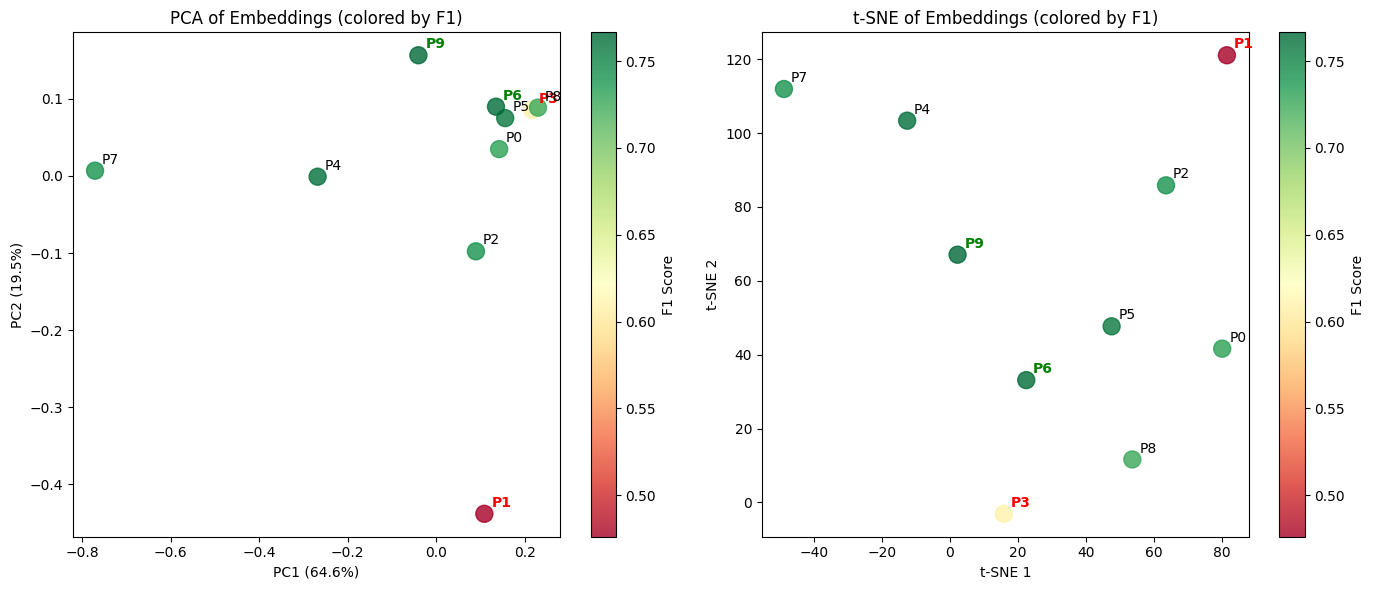

In [63]:
# Visualize embeddings with PCA/t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

ax1 = axes[0]
scatter = ax1.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], 
                      c=df_prompts['f1_mean'], cmap='RdYlGn', s=150, alpha=0.8)
for i, (x, y) in enumerate(embeddings_pca):
    color = 'red' if i in worst_prompts else 'green' if i in best_prompts else 'black'
    ax1.annotate(f'P{i}', (x, y), textcoords="offset points", xytext=(5, 5), 
                 fontsize=10, color=color, fontweight='bold' if i in worst_prompts + best_prompts else 'normal')
plt.colorbar(scatter, ax=ax1, label='F1 Score')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('PCA of Embeddings (colored by F1)')

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(embeddings)-1))
embeddings_tsne = tsne.fit_transform(embeddings)

ax2 = axes[1]
scatter2 = ax2.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], 
                       c=df_prompts['f1_mean'], cmap='RdYlGn', s=150, alpha=0.8)
for i, (x, y) in enumerate(embeddings_tsne):
    color = 'red' if i in worst_prompts else 'green' if i in best_prompts else 'black'
    ax2.annotate(f'P{i}', (x, y), textcoords="offset points", xytext=(5, 5), 
                 fontsize=10, color=color, fontweight='bold' if i in worst_prompts + best_prompts else 'normal')
plt.colorbar(scatter2, ax=ax2, label='F1 Score')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_title('t-SNE of Embeddings (colored by F1)')

plt.tight_layout()
plt.savefig(str(ANALYSIS_DIR / 'embeddings_visualization.png'), dpi=150)
plt.show()

In [64]:
# Correlation between embedding metrics and F1
print("=" * 70)
print("CORRELATION: EMBEDDING FEATURES vs F1")
print("=" * 70)

emb_features = ['emb_mean_dist', 'emb_min_dist', 'emb_max_dist', 'emb_norm', 'emb_mean', 'emb_std']

print("\n📊 Pearson correlations with F1:")
for feat in emb_features:
    corr, pval = stats.pearsonr(df_prompts[feat], df_prompts['f1_mean'])
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f"  {feat:15s}: r={corr:+.3f}, p={pval:.4f} {sig}")

CORRELATION: EMBEDDING FEATURES vs F1

📊 Pearson correlations with F1:
  emb_mean_dist  : r=-0.126, p=0.7295 
  emb_min_dist   : r=-0.126, p=0.7279 
  emb_max_dist   : r=-0.459, p=0.1819 
  emb_norm       : r=-0.142, p=0.6957 
  emb_mean       : r=+0.172, p=0.6346 
  emb_std        : r=+0.556, p=0.0952 


## 5. Subtomogram Feature Analysis

In [65]:
def extract_subtomogram(tomo, x, y, z, patch_size=37):
    """Extract a subtomogram centered at (x, y, z)."""
    half = patch_size // 2
    x, y, z = int(x), int(y), int(z)
    subtomo = tomo[z-half:z+half+1, y-half:y+half+1, x-half:x+half+1]
    if subtomo.shape != (patch_size, patch_size, patch_size):
        return None
    return subtomo


def compute_subtomo_features(subtomo):
    """
    Compute multiple features from a subtomogram.
    """
    vol = subtomo.numpy() if isinstance(subtomo, torch.Tensor) else subtomo
    vol = vol.astype(np.float32)
    
    # Basic statistics
    features = {
        'mean': vol.mean(),
        'std': vol.std(),
        'min': vol.min(),
        'max': vol.max(),
        'range': vol.max() - vol.min(),
        'skewness': stats.skew(vol.flatten()),
        'kurtosis': stats.kurtosis(vol.flatten()),
    }
    
    # Energy and contrast
    features['energy'] = np.sum(vol**2)
    features['contrast'] = vol.std() / (np.abs(vol.mean()) + 1e-8)
    
    # Fourier analysis
    F = fftn(vol)
    P = np.abs(F)**2
    P_shifted = fftshift(P)
    
    # Energy in different frequency bands
    m = vol.shape[0]
    center = m // 2
    
    # Create radial frequency grid
    z_idx, y_idx, x_idx = np.ogrid[:m, :m, :m]
    r = np.sqrt((z_idx - center)**2 + (y_idx - center)**2 + (x_idx - center)**2)
    r_norm = r / (m/2)
    
    # Bands: low (0-0.15), mid (0.15-0.35), high (0.35-1.0)
    low_band = (r_norm <= 0.15)
    mid_band = (r_norm > 0.15) & (r_norm <= 0.35)
    high_band = (r_norm > 0.35)
    
    total_power = P_shifted.sum()
    features['power_low'] = P_shifted[low_band].sum() / total_power
    features['power_mid'] = P_shifted[mid_band].sum() / total_power
    features['power_high'] = P_shifted[high_band].sum() / total_power
    features['freq_ratio_mid_high'] = features['power_mid'] / (features['power_high'] + 1e-8)
    
    # Anisotropy analysis (missing wedge proxy)
    # Calculate power in different directions
    central_xy = P_shifted[center, :, :].sum()
    central_xz = P_shifted[:, center, :].sum()
    central_yz = P_shifted[:, :, center].sum()
    features['anisotropy_xy_xz'] = central_xy / (central_xz + 1e-8)
    features['anisotropy_xy_yz'] = central_xy / (central_yz + 1e-8)
    
    # Center vs edge
    border = 4
    center_cube = vol[border:-border, border:-border, border:-border]
    features['center_mean'] = center_cube.mean()
    features['center_std'] = center_cube.std()
    features['center_energy_ratio'] = np.sum(center_cube**2) / features['energy']
    
    return features


print("=" * 70)
print("EXTRACTING SUBTOMOGRAM FEATURES")
print("=" * 70)

EXTRACTING SUBTOMOGRAM FEATURES


In [66]:
# Load tomograms and extract subtomograms
tomo_cache = {}
subtomo_features = []
subtomos_data = []

for idx, row in df_prompts.iterrows():
    tomo_name = row['tomo_name']
    x, y, z = row['x'], row['y'], row['z']
    
    # Load tomogram if not in cache
    if tomo_name not in tomo_cache:
        tomo_path = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
        if tomo_path.exists():
            print(f"  Loading {tomo_name}...")
            tomo_cache[tomo_name] = load_mrc_data(str(tomo_path)).float()
        else:
            print(f"  ❌ Not found: {tomo_path}")
            continue
    
    tomo = tomo_cache[tomo_name]
    subtomo = extract_subtomogram(tomo, x, y, z, PROMPT_SIZE)
    
    if subtomo is not None:
        features = compute_subtomo_features(subtomo)
        features['prompt_idx'] = row['prompt_idx']
        subtomo_features.append(features)
        subtomos_data.append(subtomo.numpy() if isinstance(subtomo, torch.Tensor) else subtomo)
        print(f"  ✅ Prompt {row['prompt_idx']}: extracted from {tomo_name}")

df_subtomo_features = pd.DataFrame(subtomo_features)
df_prompts = df_prompts.merge(df_subtomo_features, on='prompt_idx')

print(f"\n✅ Extracted features from {len(subtomos_data)} subtomograms")

  Loading tomo_rec_4_snr1.85...
  ✅ Prompt 0: extracted from tomo_rec_4_snr1.85
  Loading tomo_rec_11_snr1.41...
  ✅ Prompt 1: extracted from tomo_rec_11_snr1.41
  Loading tomo_rec_19_snr1.62...
  ✅ Prompt 2: extracted from tomo_rec_19_snr1.62
  ✅ Prompt 3: extracted from tomo_rec_4_snr1.85
  ✅ Prompt 4: extracted from tomo_rec_19_snr1.62
  ✅ Prompt 5: extracted from tomo_rec_11_snr1.41
  ✅ Prompt 6: extracted from tomo_rec_19_snr1.62
  Loading tomo_rec_0_snr1.63...
  ✅ Prompt 7: extracted from tomo_rec_0_snr1.63
  ✅ Prompt 8: extracted from tomo_rec_11_snr1.41
  ✅ Prompt 9: extracted from tomo_rec_11_snr1.41

✅ Extracted features from 10 subtomograms


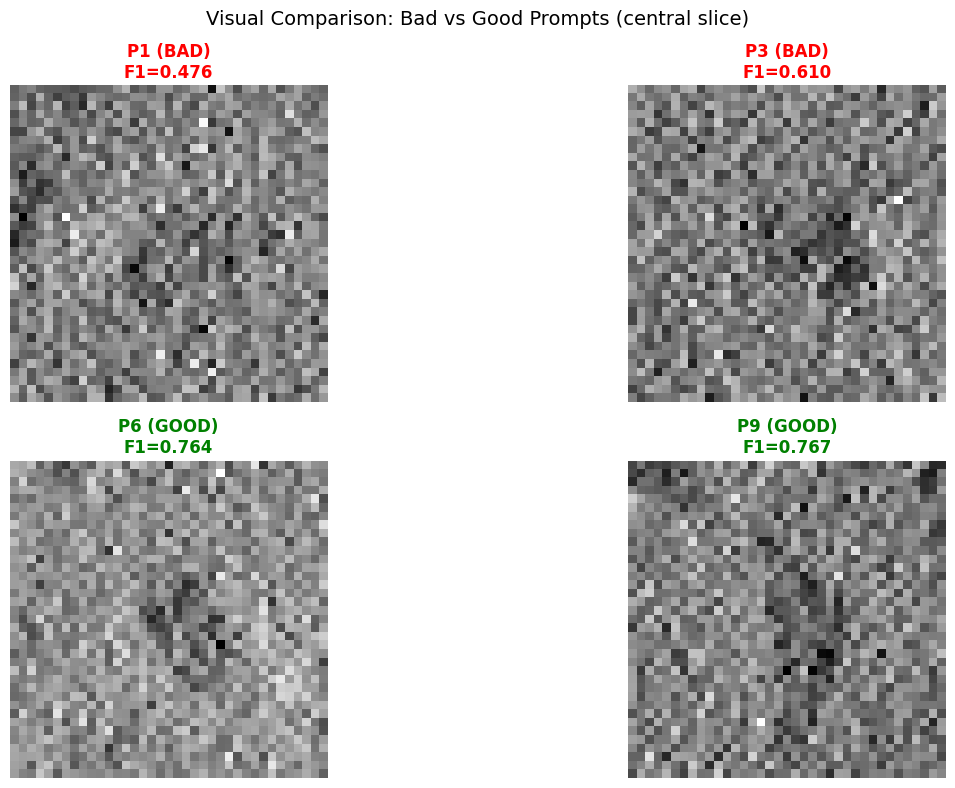

In [67]:
# Visualize good vs bad subtomograms
fig, axes = plt.subplots(2, max(len(worst_prompts), len(best_prompts)), 
                          figsize=(15, 8))

# Top row: bad prompts
for i, prompt_idx in enumerate(worst_prompts):
    ax = axes[0, i]
    subtomo = subtomos_data[prompt_idx]
    central_slice = subtomo[PROMPT_SIZE // 2]
    ax.imshow(central_slice, cmap='gray')
    ax.set_title(f'P{prompt_idx} (BAD)\nF1={df_prompts[df_prompts["prompt_idx"]==prompt_idx]["f1_mean"].values[0]:.3f}',
                 color='red', fontweight='bold')
    ax.axis('off')

# Bottom row: good prompts
for i, prompt_idx in enumerate(best_prompts):
    ax = axes[1, i]
    subtomo = subtomos_data[prompt_idx]
    central_slice = subtomo[PROMPT_SIZE // 2]
    ax.imshow(central_slice, cmap='gray')
    ax.set_title(f'P{prompt_idx} (GOOD)\nF1={df_prompts[df_prompts["prompt_idx"]==prompt_idx]["f1_mean"].values[0]:.3f}',
                 color='green', fontweight='bold')
    ax.axis('off')

# Hide empty axes
for row in axes:
    for ax in row:
        if not ax.images:
            ax.axis('off')

plt.suptitle('Visual Comparison: Bad vs Good Prompts (central slice)', fontsize=14)
plt.tight_layout()
plt.savefig(str(ANALYSIS_DIR / 'subtomos_good_vs_bad.png'), dpi=150)
plt.show()

In [68]:
# Compare subtomogram features
print("=" * 70)
print("FEATURE COMPARISON: GOOD vs BAD")
print("=" * 70)

feature_cols = ['mean', 'std', 'contrast', 'skewness', 'kurtosis', 
                'power_low', 'power_mid', 'power_high', 'freq_ratio_mid_high',
                'anisotropy_xy_xz', 'anisotropy_xy_yz', 'center_energy_ratio']

print("\n📊 Feature statistics:")
print("\n" + "="*80)
print(f"{'Feature':<25} {'Bad Mean':>12} {'Bad Std':>10} {'Good Mean':>12} {'Good Std':>10} {'Diff':>10}")
print("="*80)

significant_features = []
for feat in feature_cols:
    bad_vals = df_prompts[df_prompts['category'] == 'bad'][feat].values
    good_vals = df_prompts[df_prompts['category'] == 'good'][feat].values
    
    bad_mean = bad_vals.mean()
    bad_std = bad_vals.std()
    good_mean = good_vals.mean()
    good_std = good_vals.std()
    diff = bad_mean - good_mean
    
    # Statistical test (if enough samples)
    if len(bad_vals) > 1 and len(good_vals) > 1:
        _, pval = stats.mannwhitneyu(bad_vals, good_vals, alternative='two-sided')
        if pval < 0.1:
            significant_features.append((feat, diff, pval))
    
    print(f"{feat:<25} {bad_mean:>12.4f} {bad_std:>10.4f} {good_mean:>12.4f} {good_std:>10.4f} {diff:>+10.4f}")

print("\n⚠️ Features with notable difference (p < 0.1):")
for feat, diff, pval in significant_features:
    print(f"  - {feat}: diff={diff:+.4f}, p={pval:.4f}")

FEATURE COMPARISON: GOOD vs BAD

📊 Feature statistics:

Feature                       Bad Mean    Bad Std    Good Mean   Good Std       Diff
mean                           -0.0045     0.0244       0.0053     0.0026    -0.0098
std                             0.6313     0.0833       0.6660     0.0427    -0.0347
contrast                       27.4953     8.5186     174.1345    95.1835  -146.6392
skewness                       -0.1002     0.0213      -0.0596     0.0164    -0.0406
kurtosis                        0.1040     0.0028       0.0781     0.0313    +0.0259
power_low                       0.0499     0.0002       0.0471     0.0057    +0.0028
power_mid                       0.0691     0.0089       0.0638     0.0075    +0.0053
power_high                      0.8809     0.0091       0.8891     0.0131    -0.0082
freq_ratio_mid_high             0.0786     0.0109       0.0719     0.0095    +0.0067
anisotropy_xy_xz                2.9058     0.0084       3.0749     0.0571    -0.1691
anisotrop

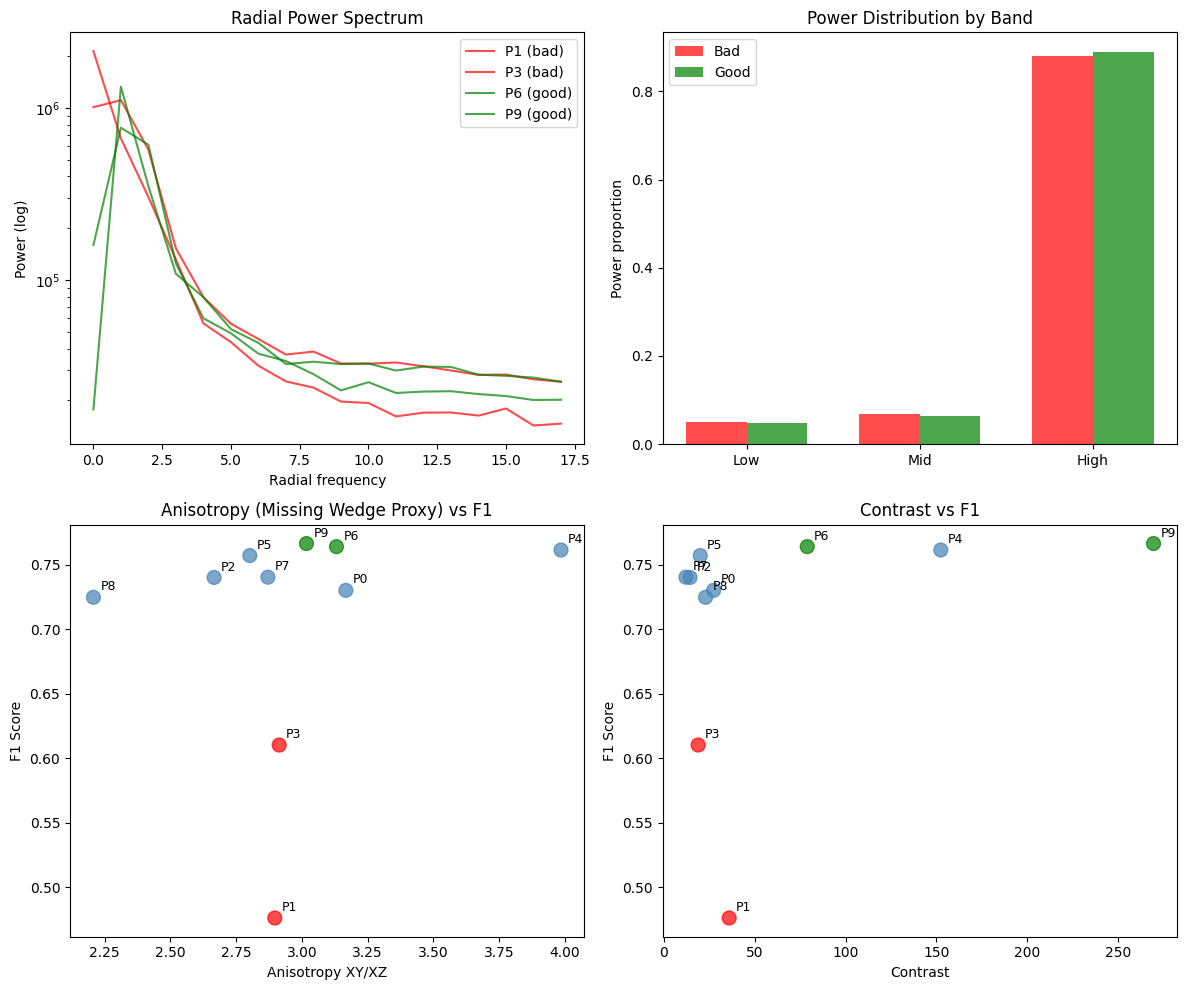

In [69]:
# Visualize power spectra
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Calculate radial power spectra
def radial_power_spectrum(vol):
    """Calculate average radial power spectrum."""
    F = fftn(vol)
    P = np.abs(fftshift(F))**2
    
    m = vol.shape[0]
    center = m // 2
    z_idx, y_idx, x_idx = np.ogrid[:m, :m, :m]
    r = np.sqrt((z_idx - center)**2 + (y_idx - center)**2 + (x_idx - center)**2).astype(int)
    
    max_r = center
    radial_profile = np.zeros(max_r)
    for i in range(max_r):
        mask = (r == i)
        if mask.any():
            radial_profile[i] = P[mask].mean()
    
    return radial_profile

# Plot spectra
ax1 = axes[0, 0]
for prompt_idx in worst_prompts:
    spectrum = radial_power_spectrum(subtomos_data[prompt_idx])
    ax1.semilogy(spectrum, 'r-', alpha=0.7, label=f'P{prompt_idx} (bad)')
for prompt_idx in best_prompts:
    spectrum = radial_power_spectrum(subtomos_data[prompt_idx])
    ax1.semilogy(spectrum, 'g-', alpha=0.7, label=f'P{prompt_idx} (good)')
ax1.set_xlabel('Radial frequency')
ax1.set_ylabel('Power (log)')
ax1.set_title('Radial Power Spectrum')
ax1.legend()

# Plot frequency distribution
ax2 = axes[0, 1]
x = np.arange(3)
width = 0.35
bad_powers = df_prompts[df_prompts['category'] == 'bad'][['power_low', 'power_mid', 'power_high']].mean().values
good_powers = df_prompts[df_prompts['category'] == 'good'][['power_low', 'power_mid', 'power_high']].mean().values
ax2.bar(x - width/2, bad_powers, width, label='Bad', color='red', alpha=0.7)
ax2.bar(x + width/2, good_powers, width, label='Good', color='green', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(['Low', 'Mid', 'High'])
ax2.set_ylabel('Power proportion')
ax2.set_title('Power Distribution by Band')
ax2.legend()

# Plot anisotropy
ax3 = axes[1, 0]
ax3.scatter(df_prompts['anisotropy_xy_xz'], df_prompts['f1_mean'], 
            c=[color_map[c] for c in df_prompts['category']], s=100, alpha=0.7)
for _, row in df_prompts.iterrows():
    ax3.annotate(f"P{int(row['prompt_idx'])}", 
                 (row['anisotropy_xy_xz'], row['f1_mean']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
ax3.set_xlabel('Anisotropy XY/XZ')
ax3.set_ylabel('F1 Score')
ax3.set_title('Anisotropy (Missing Wedge Proxy) vs F1')

# Plot contrast vs F1
ax4 = axes[1, 1]
ax4.scatter(df_prompts['contrast'], df_prompts['f1_mean'], 
            c=[color_map[c] for c in df_prompts['category']], s=100, alpha=0.7)
for _, row in df_prompts.iterrows():
    ax4.annotate(f"P{int(row['prompt_idx'])}", 
                 (row['contrast'], row['f1_mean']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
ax4.set_xlabel('Contrast')
ax4.set_ylabel('F1 Score')
ax4.set_title('Contrast vs F1')

plt.tight_layout()
plt.savefig(str(ANALYSIS_DIR / 'frequency_analysis.png'), dpi=150)
plt.show()

## 6. Position and Tomogram SNR Analysis

SNR AND POSITION ANALYSIS


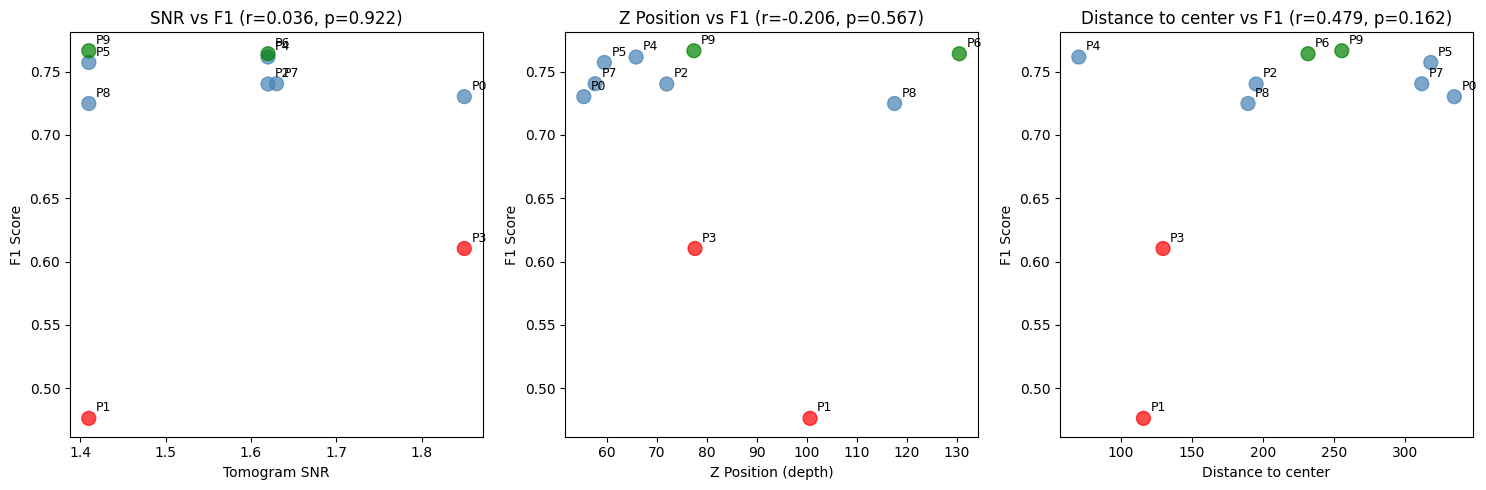


📊 SNR comparison:
  BAD prompts:  SNR = [1.41 1.85]
  GOOD prompts: SNR = [1.62 1.41]


In [70]:
print("=" * 70)
print("SNR AND POSITION ANALYSIS")
print("=" * 70)

# SNR vs F1
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = axes[0]
ax1.scatter(df_prompts['snr'], df_prompts['f1_mean'], 
            c=[color_map[c] for c in df_prompts['category']], s=100, alpha=0.7)
for _, row in df_prompts.iterrows():
    ax1.annotate(f"P{int(row['prompt_idx'])}", 
                 (row['snr'], row['f1_mean']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
corr, pval = stats.pearsonr(df_prompts['snr'], df_prompts['f1_mean'])
ax1.set_xlabel('Tomogram SNR')
ax1.set_ylabel('F1 Score')
ax1.set_title(f'SNR vs F1 (r={corr:.3f}, p={pval:.3f})')

# Z position vs F1 (depth)
ax2 = axes[1]
ax2.scatter(df_prompts['z'], df_prompts['f1_mean'], 
            c=[color_map[c] for c in df_prompts['category']], s=100, alpha=0.7)
for _, row in df_prompts.iterrows():
    ax2.annotate(f"P{int(row['prompt_idx'])}", 
                 (row['z'], row['f1_mean']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
corr_z, pval_z = stats.pearsonr(df_prompts['z'], df_prompts['f1_mean'])
ax2.set_xlabel('Z Position (depth)')
ax2.set_ylabel('F1 Score')
ax2.set_title(f'Z Position vs F1 (r={corr_z:.3f}, p={pval_z:.3f})')

# Distance to center vs F1
# Calculate distance to tomogram center (assuming ~512x512x200 approx)
tomo_center = np.array([256, 256, 100])  # Approximate
df_prompts['dist_to_center'] = np.sqrt(
    (df_prompts['x'] - tomo_center[0])**2 + 
    (df_prompts['y'] - tomo_center[1])**2 + 
    (df_prompts['z'] - tomo_center[2])**2
)

ax3 = axes[2]
ax3.scatter(df_prompts['dist_to_center'], df_prompts['f1_mean'], 
            c=[color_map[c] for c in df_prompts['category']], s=100, alpha=0.7)
for _, row in df_prompts.iterrows():
    ax3.annotate(f"P{int(row['prompt_idx'])}", 
                 (row['dist_to_center'], row['f1_mean']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
corr_d, pval_d = stats.pearsonr(df_prompts['dist_to_center'], df_prompts['f1_mean'])
ax3.set_xlabel('Distance to center')
ax3.set_ylabel('F1 Score')
ax3.set_title(f'Distance to center vs F1 (r={corr_d:.3f}, p={pval_d:.3f})')

plt.tight_layout()
plt.savefig(str(ANALYSIS_DIR / 'position_snr_analysis.png'), dpi=150)
plt.show()

# Compare SNR between good and bad
print("\n📊 SNR comparison:")
print(f"  BAD prompts:  SNR = {df_prompts[df_prompts['category']=='bad']['snr'].values}")
print(f"  GOOD prompts: SNR = {df_prompts[df_prompts['category']=='good']['snr'].values}")

## 7. Summary of Discriminative Features

In [71]:
print("=" * 70)
print("SUMMARY OF DISCRIMINATIVE FEATURES")
print("=" * 70)

# Compile all features
all_features = [
    'snr', 'x', 'y', 'z', 'dist_to_center',
    'euler_x', 'euler_y', 'euler_z',
    'emb_mean_dist', 'emb_norm', 'emb_std',
    'mean', 'std', 'contrast', 'skewness', 'kurtosis',
    'power_low', 'power_mid', 'power_high', 'freq_ratio_mid_high',
    'anisotropy_xy_xz', 'anisotropy_xy_yz', 'center_energy_ratio'
]

# Calculate correlation with F1 for each feature
correlations = []
for feat in all_features:
    if feat in df_prompts.columns:
        corr, pval = stats.pearsonr(df_prompts[feat].dropna(), 
                                     df_prompts.loc[df_prompts[feat].notna(), 'f1_mean'])
        correlations.append({'feature': feat, 'correlation': corr, 'p_value': pval})

df_corr = pd.DataFrame(correlations).sort_values('correlation', key=abs, ascending=False)

print("\n📊 Correlations with F1 Score (sorted by magnitude):")
print("="*60)
for _, row in df_corr.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else ''
    print(f"  {row['feature']:<25} r={row['correlation']:+.3f}  p={row['p_value']:.4f} {sig}")

# Save results
df_corr.to_csv(ANALYSIS_DIR / 'feature_correlations.csv', index=False)

SUMMARY OF DISCRIMINATIVE FEATURES

📊 Correlations with F1 Score (sorted by magnitude):
  euler_x                   r=+0.625  p=0.0534 
  emb_std                   r=+0.556  p=0.0952 
  dist_to_center            r=+0.479  p=0.1616 
  euler_y                   r=-0.324  p=0.3616 
  contrast                  r=+0.307  p=0.3878 
  y                         r=+0.208  p=0.5641 
  z                         r=-0.206  p=0.5675 
  x                         r=+0.190  p=0.5989 
  mean                      r=-0.159  p=0.6617 
  anisotropy_xy_xz          r=+0.156  p=0.6665 
  euler_z                   r=-0.148  p=0.6827 
  emb_norm                  r=-0.142  p=0.6957 
  emb_mean_dist             r=-0.126  p=0.7295 
  skewness                  r=+0.125  p=0.7306 
  freq_ratio_mid_high       r=+0.104  p=0.7747 
  power_mid                 r=+0.102  p=0.7797 
  power_high                r=-0.091  p=0.8023 
  power_low                 r=+0.076  p=0.8347 
  center_energy_ratio       r=+0.075  p=0.8365 


In [72]:
# Create summary table of good vs bad prompts
print("=" * 70)
print("SUMMARY TABLE: GOOD vs BAD")
print("=" * 70)

# Select most relevant features
key_features = ['snr', 'z', 'euler_z', 'contrast', 'freq_ratio_mid_high', 
                'anisotropy_xy_xz', 'emb_mean_dist', 'power_high']

summary_data = []
for feat in key_features:
    if feat in df_prompts.columns:
        bad_mean = df_prompts[df_prompts['category'] == 'bad'][feat].mean()
        good_mean = df_prompts[df_prompts['category'] == 'good'][feat].mean()
        all_mean = df_prompts[feat].mean()
        
        summary_data.append({
            'Feature': feat,
            'Bad': f"{bad_mean:.4f}",
            'Good': f"{good_mean:.4f}",
            'All': f"{all_mean:.4f}",
            'Diff (Bad-Good)': f"{bad_mean - good_mean:+.4f}"
        })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

df_summary.to_csv(ANALYSIS_DIR / 'bad_vs_good_summary.csv', index=False)

SUMMARY TABLE: GOOD vs BAD


,Feature,Bad,Good,All,Diff (Bad-Good)
0,snr,1.6300,1.5150,1.5830,+0.1150
1,z,89.1277,103.9436,81.3985,-14.8160
2,euler_z,27.7669,45.8240,1.2255,-18.0570
3,contrast,27.4953,174.1345,65.3056,-146.6392
4,freq_ratio_mid_high,0.0786,0.0719,0.0861,+0.0067
5,anisotropy_xy_xz,2.9058,3.0749,2.9663,-0.1691
6,emb_mean_dist,0.1542,0.0957,0.1461,+0.0585
7,power_high,0.8809,0.8891,0.8702,-0.0082


In [73]:
# Save complete DataFrame with all features
df_prompts.to_csv(ANALYSIS_DIR / 'prompts_full_features.csv', index=False)
print(f"\n✅ Complete DataFrame saved to: {ANALYSIS_DIR / 'prompts_full_features.csv'}")

# Show all features of problematic prompts
print("\n" + "=" * 70)
print("COMPLETE FEATURES OF PROBLEMATIC PROMPTS")
print("=" * 70)

print("\n🔴 BAD prompts:")
display(df_prompts[df_prompts['category'] == 'bad'].T)

print("\n🟢 GOOD prompts:")
display(df_prompts[df_prompts['category'] == 'good'].T)


✅ Complete DataFrame saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/underperforming_analysis/prompts_full_features.csv

COMPLETE FEATURES OF PROBLEMATIC PROMPTS

🔴 BAD prompts:


,1,3
prompt_idx,1,3
tomo_name,tomo_rec_11_snr1.41,tomo_rec_4_snr1.85
x,173.395637,245.527963
y,337.563676,383.464252
z,100.634592,77.62074
q1,-0.673936,-0.393876
q2,-0.627778,0.175664
q3,0.382405,-0.297672
q4,-0.073966,0.851701
snr,1.41,1.85



🟢 GOOD prompts:


,6,9
prompt_idx,6,9
tomo_name,tomo_rec_19_snr1.62,tomo_rec_11_snr1.41
x,61.920452,136.715054
y,378.827728,480.728096
z,130.491091,77.396209
q1,-0.618175,-0.216686
q2,0.017371,-0.765773
q3,0.226239,-0.174306
q4,-0.752578,-0.579876
snr,1.62,1.41


## 8. Identify Candidates Similar to Bad Prompts

Now we will search for more particles in the dataset that have characteristics similar to the problematic prompts to validate our hypotheses.

In [74]:
print("=" * 70)
print("SEARCHING FOR CANDIDATES SIMILAR TO BAD PROMPTS")
print("=" * 70)

# Load CSV with all particles
UPDATED_CSV = EXP4_DATA_DIR / "tomos_motif_list_updated.csv"

if UPDATED_CSV.exists():
    df_all = pd.read_csv(UPDATED_CSV, sep='\t')
    df_thy = df_all[df_all['Label'] == THYROGLOBULIN_LABEL].copy()
    print(f"Total thyroglobulin particles: {len(df_thy)}")
    
    # Extract tomogram name and SNR
    df_thy['tomo_name'] = df_thy['Tomo3D'].apply(lambda x: Path(x).stem)
    df_thy['snr'] = df_thy['tomo_name'].apply(
        lambda x: float(x.split('snr')[1]) if 'snr' in x else np.nan
    )
    
    # Filter only training tomograms
    df_thy_train = df_thy[df_thy['tomo_name'].isin(EXP4_TRAIN_POOL)].copy()
    print(f"Particles in training pool: {len(df_thy_train)}")
else:
    print(f"❌ CSV not found: {UPDATED_CSV}")
    print("   Run the main exp4 notebook first")
    df_thy_train = None

SEARCHING FOR CANDIDATES SIMILAR TO BAD PROMPTS
Total thyroglobulin particles: 3327
Particles in training pool: 2705


In [75]:
if df_thy_train is not None:
    # Identify which features define bad prompts
    # Based on the previous analysis
    
    bad_prompts_data = df_prompts[df_prompts['category'] == 'bad']
    
    print("\n📋 Criteria for finding candidates similar to bad prompts:")
    print("   (based on the most discriminative features)")
    
    # Get feature ranges from bad prompts
    criteria = {}
    
    # 1. Orientation ranges (euler angles)
    for angle in ['euler_x', 'euler_y', 'euler_z']:
        bad_min = bad_prompts_data[angle].min()
        bad_max = bad_prompts_data[angle].max()
        criteria[angle] = (bad_min, bad_max)
        print(f"   - {angle}: [{bad_min:.1f}°, {bad_max:.1f}°]")
    
    # 2. Similar SNR
    bad_snr_mean = bad_prompts_data['snr'].mean()
    bad_snr_std = bad_prompts_data['snr'].std()
    criteria['snr'] = (bad_snr_mean - bad_snr_std, bad_snr_mean + bad_snr_std)
    print(f"   - SNR: [{criteria['snr'][0]:.2f}, {criteria['snr'][1]:.2f}]")
    
    # Convert quaternions to euler in df_thy_train
    euler_train = []
    for _, row in df_thy_train.iterrows():
        euler = quaternion_to_euler(row['Q1'], row['Q2'], row['Q3'], row['Q4'])
        euler_train.append({'euler_x': euler[0], 'euler_y': euler[1], 'euler_z': euler[2]})
    
    df_euler_train = pd.DataFrame(euler_train)
    df_thy_train = pd.concat([df_thy_train.reset_index(drop=True), df_euler_train], axis=1)
    
    print(f"\n✅ Added Euler angles to {len(df_thy_train)} particles")


📋 Criteria for finding candidates similar to bad prompts:
   (based on the most discriminative features)
   - euler_x: [-151.4°, -51.0°]
   - euler_y: [3.7°, 37.5°]
   - euler_z: [-40.3°, 95.8°]
   - SNR: [1.32, 1.94]

✅ Added Euler angles to 2705 particles


In [76]:
if df_thy_train is not None:
    # Search for particles with similar orientations to bad prompts
    # Using quaternion angular distance as main criterion
    
    print("\n🔍 Searching for particles with similar orientations to bad prompts...")
    
    # Quaternions of bad prompts
    bad_quats = bad_prompts_data[['q1', 'q2', 'q3', 'q4']].values
    
    # Calculate minimum angular distance to any bad prompt for each particle
    min_dist_to_bad = []
    for _, row in df_thy_train.iterrows():
        q = [row['Q1'], row['Q2'], row['Q3'], row['Q4']]
        min_dist = min(quaternion_angular_distance(q, bq) for bq in bad_quats)
        min_dist_to_bad.append(min_dist)
    
    df_thy_train['min_dist_to_bad'] = min_dist_to_bad
    
    # Filter particles close to bad prompts (< 30° angular distance)
    similar_threshold = 30.0
    df_similar_to_bad = df_thy_train[df_thy_train['min_dist_to_bad'] < similar_threshold].copy()
    
    print(f"\n📊 Results:")
    print(f"   Particles with similar orientation to bad prompts (<{similar_threshold}°): {len(df_similar_to_bad)}")
    print(f"   Distribution by tomogram:")
    print(df_similar_to_bad['tomo_name'].value_counts().head(10))


🔍 Searching for particles with similar orientations to bad prompts...

📊 Results:
   Particles with similar orientation to bad prompts (<30.0°): 41
   Distribution by tomogram:
tomo_name
tomo_rec_13_snr1.1     5
tomo_rec_24_snr1.39    4
tomo_rec_21_snr0.34    4
tomo_rec_20_snr0.73    4
tomo_rec_15_snr1.03    3
tomo_rec_0_snr1.63     3
tomo_rec_10_snr0.97    3
tomo_rec_4_snr1.85     3
tomo_rec_14_snr0.43    2
tomo_rec_12_snr1.39    2
Name: count, dtype: int64


In [77]:
if df_thy_train is not None and len(df_similar_to_bad) > 0:
    # Select candidates for new inference
    # Prioritizing diversity of tomograms and closeness to bad prompts
    
    print("\n=" * 70)
    print("SELECTING CANDIDATES FOR NEW INFERENCE")
    print("=" * 70)
    
    # Sort by closeness to bad prompts
    df_similar_sorted = df_similar_to_bad.sort_values('min_dist_to_bad')
    
    # Select top 10 candidates (1 per tomogram if possible)
    selected_candidates = []
    used_tomos = set()
    
    for _, row in df_similar_sorted.iterrows():
        tomo = row['tomo_name']
        if tomo not in used_tomos or len(selected_candidates) < 5:
            selected_candidates.append(row)
            used_tomos.add(tomo)
        if len(selected_candidates) >= 10:
            break
    
    df_new_candidates = pd.DataFrame(selected_candidates)
    
    print(f"\n📋 Selected {len(df_new_candidates)} new candidates:")
    display(df_new_candidates[['tomo_name', 'X', 'Y', 'Z', 'Q1', 'Q2', 'Q3', 'Q4', 
                               'euler_x', 'euler_y', 'euler_z', 'min_dist_to_bad', 'snr']])
    
    # Save candidates
    df_new_candidates.to_csv(ANALYSIS_DIR / 'similar_bad_candidates.csv', index=False)
    print(f"\n✅ Candidates saved to: {ANALYSIS_DIR / 'similar_bad_candidates.csv'}")


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
SELECTING CANDIDATES FOR NEW INFERENCE

📋 Selected 10 new candidates:


,tomo_name,X,Y,Z,Q1,Q2,Q3,Q4,euler_x,euler_y,euler_z,min_dist_to_bad,snr
553,tomo_rec_4_snr1.85,2458.335106,3839.414540,777.173348,-0.393876,0.175664,-0.297672,0.851701,-50.999524,3.711629,-40.300149,0.000000,1.85
934,tomo_rec_11_snr1.41,1736.114193,3379.837569,1007.598269,-0.673936,-0.627778,0.382405,-0.073966,-151.359426,37.466818,95.834012,0.000000,1.41
2211,tomo_rec_21_snr0.34,2106.298533,3734.351230,762.799800,-0.374197,0.119676,-0.286541,0.873813,-46.265481,-0.303524,-36.181037,7.369801,0.34
967,tomo_rec_12_snr1.39,2792.532156,2396.172575,604.133152,-0.377725,0.137062,-0.366757,0.839063,-47.325926,-2.697309,-46.038411,9.370759,1.39
2514,tomo_rec_23_snr0.29,3647.982996,3711.639519,1685.354901,0.649302,0.696425,-0.296488,0.074128,-158.721638,29.226848,99.619046,12.921171,0.29
1148,tomo_rec_13_snr1.1,2589.991443,5345.264376,1378.401072,0.426236,-0.251081,0.352716,-0.794275,-59.133377,5.634015,-51.087455,13.103932,1.10
2061,tomo_rec_20_snr0.73,5447.326294,1452.152724,1677.761016,-0.377670,0.036666,-0.340606,0.860237,-43.459634,-11.197393,-38.726883,16.817204,0.73
2635,tomo_rec_24_snr1.39,4849.912924,3154.057240,1340.023031,0.504741,-0.271323,0.264009,-0.775835,-69.670947,8.887338,-43.777286,19.310533,1.39
1412,tomo_rec_15_snr1.03,4800.786355,674.576179,1461.524314,0.346475,-0.178543,0.144241,-0.909545,-44.402121,12.993047,-23.344234,19.585787,1.03
6,tomo_rec_0_snr1.63,1475.456728,5953.252267,868.229292,-0.539651,0.110784,-0.327885,0.767460,-66.432982,-10.593614,-39.319685,20.993352,1.63



✅ Candidates saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/underperforming_analysis/similar_bad_candidates.csv


## 9. Conclusions and Next Steps

In [78]:
print("=" * 70)
print("ANALYSIS CONCLUSIONS")
print("=" * 70)

print(f"""
📊 SUMMARY OF FINDINGS:

1. IDENTIFIED PROMPTS:
   - Worst performance: {worst_prompts}
   - Best performance: {best_prompts}
   - F1 difference: {df_by_prompt['f1_mean'].max() - df_by_prompt['f1_mean'].min():.4f}

2. MAIN CHARACTERISTICS OF BAD PROMPTS:
""")

# List most discriminative features
top_discriminative = df_corr[abs(df_corr['correlation']) > 0.3]
if len(top_discriminative) > 0:
    print("   Features with highest correlation to F1:")
    for _, row in top_discriminative.iterrows():
        print(f"   - {row['feature']}: r={row['correlation']:+.3f}")

print(f"""
3. SIMILAR CANDIDATES FOUND:
   - Particles with similar orientation to bad prompts: {len(df_similar_to_bad) if df_thy_train is not None else 'N/A'}
   - Candidates selected for new inference: {len(df_new_candidates) if df_thy_train is not None else 'N/A'}

4. NEXT STEPS:
   a) Extract subtomograms from new candidates
   b) Generate embeddings with TomoTwin
   c) Run inference with fine-tuned model
   d) Compare results to validate hypotheses
""")

# Save summary
summary_text = f"""
UNDERPERFORMING PROMPTS ANALYSIS
================================

Bad prompts: {worst_prompts}
Good prompts: {best_prompts}

F1 difference: {df_by_prompt['f1_mean'].max() - df_by_prompt['f1_mean'].min():.4f}

Discriminative features (|r| > 0.3):
{top_discriminative[['feature', 'correlation', 'p_value']].to_string() if len(top_discriminative) > 0 else 'None'}

Similar candidates found: {len(df_similar_to_bad) if df_thy_train is not None else 'N/A'}
"""

with open(ANALYSIS_DIR / 'analysis_summary.txt', 'w') as f:
    f.write(summary_text)

print(f"\n✅ Summary saved to: {ANALYSIS_DIR / 'analysis_summary.txt'}")

ANALYSIS CONCLUSIONS

📊 SUMMARY OF FINDINGS:

1. IDENTIFIED PROMPTS:
   - Worst performance: [1, 3]
   - Best performance: [6, 9]
   - F1 difference: 0.2905

2. MAIN CHARACTERISTICS OF BAD PROMPTS:

   Features with highest correlation to F1:
   - euler_x: r=+0.625
   - emb_std: r=+0.556
   - dist_to_center: r=+0.479
   - euler_y: r=-0.324
   - contrast: r=+0.307

3. SIMILAR CANDIDATES FOUND:
   - Particles with similar orientation to bad prompts: 41
   - Candidates selected for new inference: 10

4. NEXT STEPS:
   a) Extract subtomograms from new candidates
   b) Generate embeddings with TomoTwin
   c) Run inference with fine-tuned model
   d) Compare results to validate hypotheses


✅ Summary saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/underperforming_analysis/analysis_summary.txt
